# 🔍 Notebook 02: Análisis Exploratorio de Datos (EDA)
** Hipótesis de Trabajo:** Existe una brecha generacional donde los adultos (>35) están limitados por el *tiempo*, mientras que los jóvenes (18-35) están limitados por el *mensaje/conexión*.

---

## 1. Validación de la Representatividad
Antes de analizar opciones, debemos ver cómo se distribuyen nuestras **30 respuestas** actuales en los segmentos que creamos en el Notebook de limpieza. Esto nos dirá si tenemos una muestra equilibrada o si algún grupo está dominando la conversación.

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Localizamos la raíz del proyecto
BASE_DIR = Path.cwd().parent
# 2. Definimos las rutas a las carpetas que necesitamos
DATA_PROCESSED = BASE_DIR / "data" / "processed"
DATA_RAW = BASE_DIR / "data" / "raw"
FIGURES_DIR = BASE_DIR / "outputs" / "figures"

# Cargar el df_encuesta del notebook anterior
df = pd.read_csv(DATA_PROCESSED / "encuesta_segmentada.csv")

print(f"✅ Conexión establecida. Trabajando con {len(df)} respuestas.")

✅ Conexión establecida. Trabajando con 30 respuestas.


## 📊 Análisis de la Estructura de la Muestra
Ahora que los datos están cargados, vamos a verificar cuántos registros pertenecen a cada segmento para validar nuestra **Hipótesis Intergeneracional**.

In [21]:
df.head(5)

,timestamp,edad,2. Sexo/Género:,ocupacion,antiguedad,frecuencia,conexion,barrera,interes,horario,canal_info,grupo_etario
0,23/03/2026 16:29:45,33,Mujer,• Opositor/a o en búsqueda de empleo.,• Toda la vida.,• Nunca o casi nunca,1.0,• Los temas que se tratan no me interesan,"• Deporte o excursiones (Rutas, Camino de Sant...",• Tarde (18:00 - 19:30),"• Sí, me gustaría participar",Millenials (26-35)
1,23/03/2026 16:44:09,31,Mujer,• Trabajador/a.,• Menos de 2 años (Nuevo/a en el pueblo).,"• Solo en fechas señaladas (Navidad, Fiestas, ...",3.0,• Los horarios no coinciden con mi vida,"• Eventos sociales (Cenas, música en directo, ...",• Tarde (18:00 - 19:30),• Solo para recibir información puntual,Millenials (26-35)
2,23/03/2026 21:49:42,46,Mujer,• Trabajador/a.,Opción 3,"• Solo en fechas señaladas (Navidad, Fiestas, ...",3.0,• Los horarios no coinciden con mi vida,"• Eventos sociales (Cenas, música en directo, ...",• Mañana (11:00 - 12:30),"• Sí, me gustaría participar",Adultos (36+)
3,23/03/2026 22:18:11,28,Hombre,• Trabajador/a.,Opción 3,• Nunca o casi nunca,1.0,• Siento que es un ambiente demasiado tradicional,"• Deporte o excursiones (Rutas, Camino de Sant...",NaN,• No me interesa,Millenials (26-35)
4,23/03/2026 22:46:59,50,Mujer,• Trabajador/a.,Opción 3,"• Solo en fechas señaladas (Navidad, Fiestas, ...",2.0,• Los temas que se tratan no me interesan,"• Espiritualidad moderna (Meditación, silencio...",• Mañana (11:00 - 12:30),• Solo para recibir información puntual,Adultos (36+)


## 1. Composición de la Muestra Actual
Para validar nuestra **Hipótesis Intergeneracional**, primero observamos cómo se distribuyen las 30 respuestas en los tres grupos definidos:
* **Gen Z (18-25)**
* **Millenials (26-35)**
* **Adultos (36+)**

Esto nos permitirá ver si los "Adultos" (nuestro grupo de contraste) son suficientes para comparar.

In [ ]:
import re

def limpiar_multiseleccion(dataframe, columna):
    """
    Limpia columnas de Google Forms evitando romper frases con comas internas.
    """
    df_temp = dataframe[['grupo_etario', columna]].copy().dropna()
    
    # Solo hacemos split si la coma NO está dentro de paréntesis
    # Esto protege: "Eventos sociales (Cenas, música en directo, debates)"
    def splitting_logic(text):
        # Esta expresión regular busca comas que separan opciones principales
        return re.split(r',(?![^\(]*\))', text)

    df_temp[columna] = df_temp[columna].apply(splitting_logic)
    df_temp = df_temp.explode(columna)
    df_temp[columna] = df_temp[columna].str.strip()
    
    return df_temp

📊 Distribución por grupos:
grupo_etario
Adultos (36+)         15
Millenials (26-35)    14
Gen Z (18-25)          1
Name: count, dtype: int64


/var/folders/r0/zcybk_jx6078hqn3yvc527tm0000gn/T/ipykernel_9479/376513313.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="grupo_etario", order=["Gen Z (18-25)", "Millenials (26-35)", "Adultos (36+)"], palette="viridis")


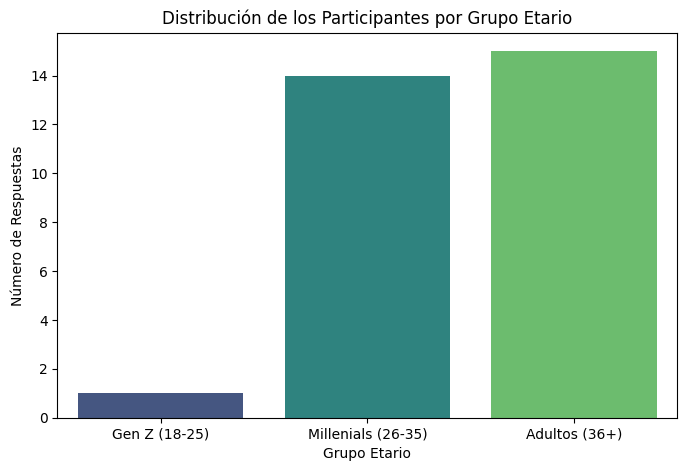

In [23]:

# 1. Ver el conteo exacto por grupo etario
resumen_grupos = df["grupo_etario"].value_counts()
print("📊 Distribución por grupos:")
print(resumen_grupos)

# 2. Visualización de la estructura de la muestra
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="grupo_etario", order=["Gen Z (18-25)", "Millenials (26-35)", "Adultos (36+)"], palette="viridis")
plt.title("Distribución de los Participantes por Grupo Etario")
plt.ylabel("Número de Respuestas")
plt.xlabel("Grupo Etario")
# ---GUARDAR GRÄFICO---
plt.savefig(FIGURES_DIR / "01_distribucion_grupos.png")
plt.show()

### ✨ Descubrimiento:
* La muestra está dividida casi al **50%** entre el público objetivo (Jóvenes) y el público de contraste (Adultos).
* Esto es ideal para nuestra hipótesis, ya que tenemos grupos de tamaños similar para comparar.

---

### 2. Nivel de Conexión Comunitaria
¿Se sienten los jóvenes menos parte de la parroquia que los adultos? Usaremos la columna 'conexion' (1-5) para comparar.

/var/folders/r0/zcybk_jx6078hqn3yvc527tm0000gn/T/ipykernel_9479/3519278609.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="grupo_etario", y="conexion",


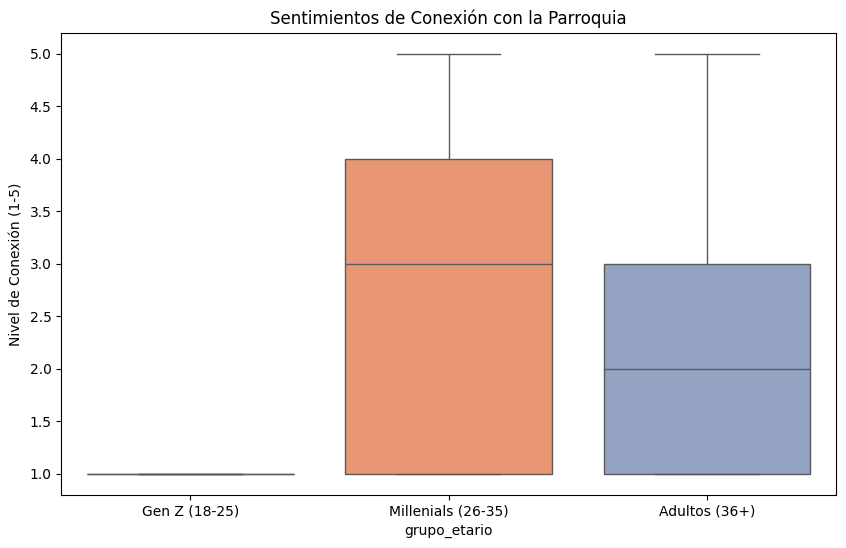

In [24]:
plt.figure(figsize=(10,6))
# Usamos 'grup_etario' en el eje X
sns.boxplot(data=df, x="grupo_etario", y="conexion",
            order=["Gen Z (18-25)", "Millenials (26-35)", "Adultos (36+)"],
            palette="Set2")
plt.title("Sentimientos de Conexión con la Parroquia")
plt.ylabel("Nivel de Conexión (1-5)")
plt.savefig(FIGURES_DIR / "02_conexion_por_grupo.png", dpi=300)
plt.show()

### 3. Análisis de Intereses y Actividades
**Pregunta:** ¿Existen diferencias entre lo que busca un joven de 18 años y lo que busca un adulto de 45 en la parroquia?

Este análisis es vital para la toma de decisiones. Si los intereses son distintos, la parroquia no puede ofrecer una "talla única" para todos; necesitará una programación segmentada.

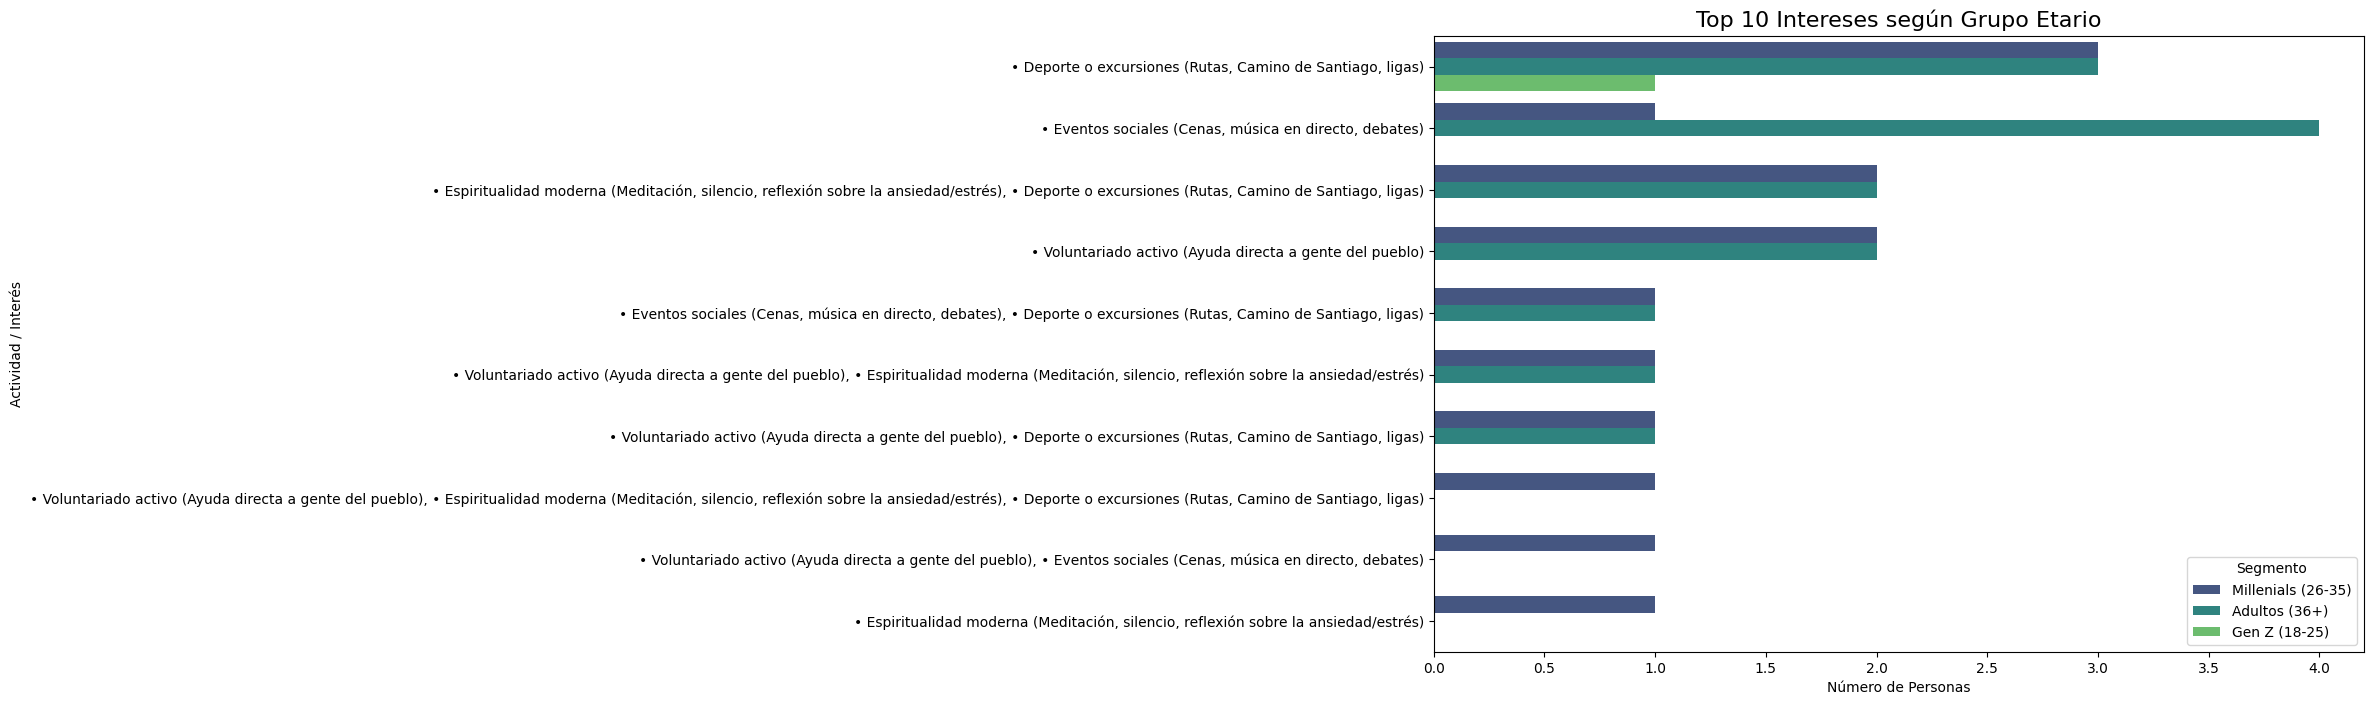

In [25]:
plt.figure(figsize=(12,8))

# Creamos el gráfico de barras horizontales segmentado por grupo etario 
sns.countplot(data=df,
              y="interes",
              hue="grupo_etario",
              palette="viridis",
              order=df["interes"].value_counts().index[:10])
plt.title("Top 10 Intereses según Grupo Etario", fontsize=16)
plt.xlabel("Número de Personas")
plt.ylabel("Actividad / Interés")
plt.legend(title="Segmento", loc="lower right")

# --- GUARDAR GRÁFICO ---
plt.savefig(FIGURES_DIR / "03_intereses_por_edad.png", dpi=300,bbox_inches="tight")
plt.show()

### ✨ Descubrimiento Clave: Intereses por Segmento

Tras analizar el Top 10 de intereses, observamos un patrón inesperado en la muestra actual:
1. **Empate Técnico:** Los *Millenials (26-35)* y los *Adultos (36+)* muestran intereses muy similares en casilas categorias, lo que sugiere que hay una base en común de actividades que podría unir a la comunidad.
2. **Dominancia Adulta en Social:** El interés por **"Eventos sociales (Cenas, música en directo, debate)"** es liderado notablemente por el grupo de adultos.
3. **Punto de Reflexión:** Los jóvenes adultos (Millenials) están empatados, pero los adultos consolidan más este deseo social.
## 3.1. Desglose de Intereses (Tratamiento de Selección Múltiple)
En la encuesta, la pregunta de intereses permitía marcar varias casillas. Para no analizar "bloques de texto", vamos a realizar una operación de **Explode**.

**Técnica:**
1. Limpiar valores nulos.
2. Dividir las cadenas por la coma (`,`).
3. Expandir la tabla para que cada interés tenga su propia fila vinculada al `grupo_etario` original.

> **💡 Nueva Hipótesis:** ¿Es posible que los adultos busquen en la parroquia ese espacio de socialización que el ritmo de vida o la falta de locales en O Milladoiro les quita, mientras que los más jóvenes buscan algo más especifico?

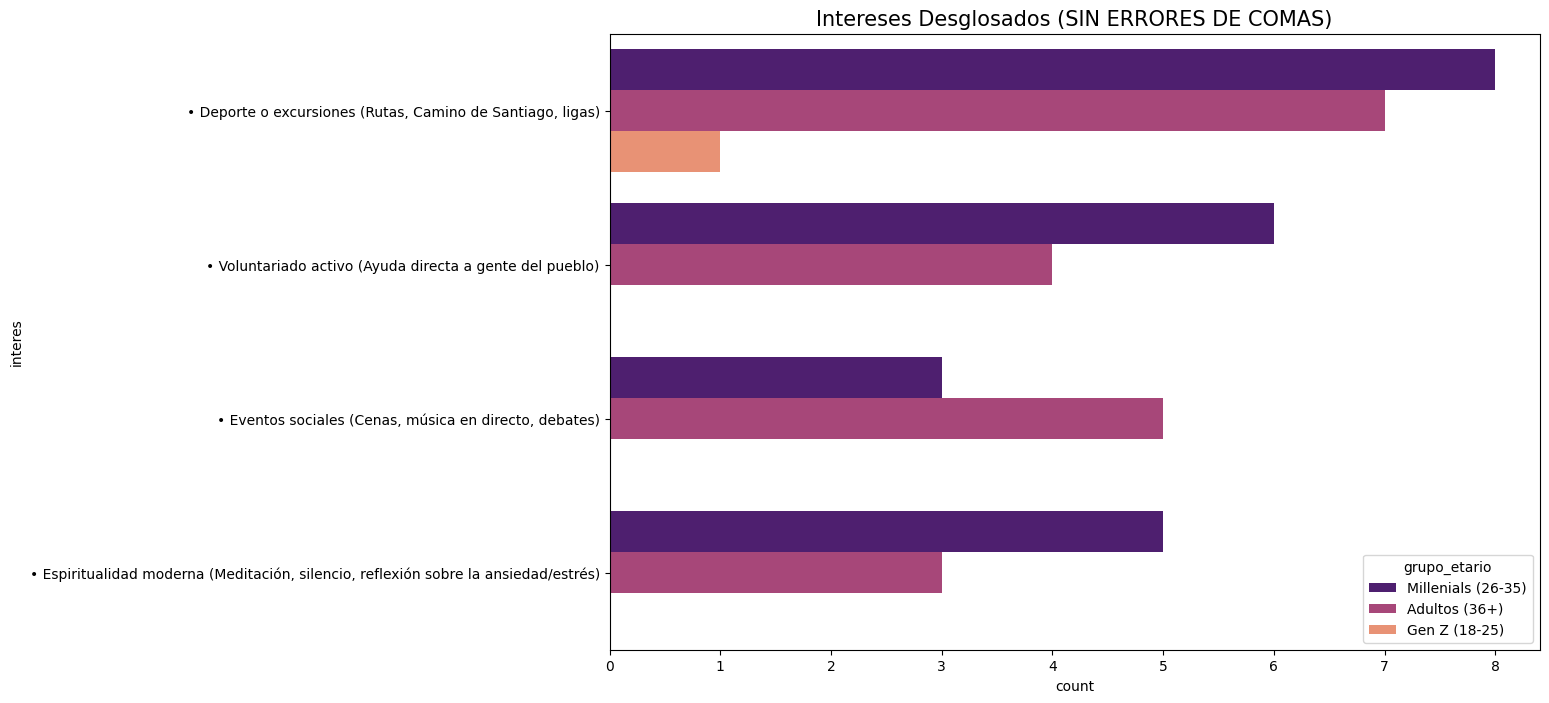

In [28]:
# 1. Usamos la función mágica
df_intereses_ok = limpiar_multiseleccion(df, 'interes')

# 2. Graficamos
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df_intereses_ok, 
    y='interes', 
    hue='grupo_etario',
    palette='magma',
    order=df_intereses_ok['interes'].value_counts().index
)

plt.title('Intereses Desglosados (SIN ERRORES DE COMAS)', fontsize=15)
plt.savefig(FIGURES_DIR / "04_intereses_final_corregido.png", dpi=300, bbox_inches='tight')
plt.show()

### ✨ Descubrimiento Crítico: El desajuste de intereses
Al desglosar las respuestas de selección múltiple, los datos revelan una realidad distinta a la suposición inicial:

* **Dominio Adulto:** El grupo de **Adultos (36+)** es el que más interés muestra por la dinamización social (música, debates, cenas). 
* **Silencio Juvenil:** Los grupos **Gen Z** y **Millennials** tienen una participación muy baja en estos intereses dentro de la muestra actual.
* **Interpretación:** Esto sugiere que la oferta de actividades "sociales" de la parroquia está conectando con los adultos, pero **no resulta atractiva para los menores de 35 años**, o bien estos últimos no se sienten invitados a esos espacios.

---

## 4. Canales de Comunicación: ¿Por dónde les hablamos?
De nada sirve crear la actividad perfecta si usamos el canal equivocado. Vamos a analizar por qué medios prefieren recibir información cada grupo.

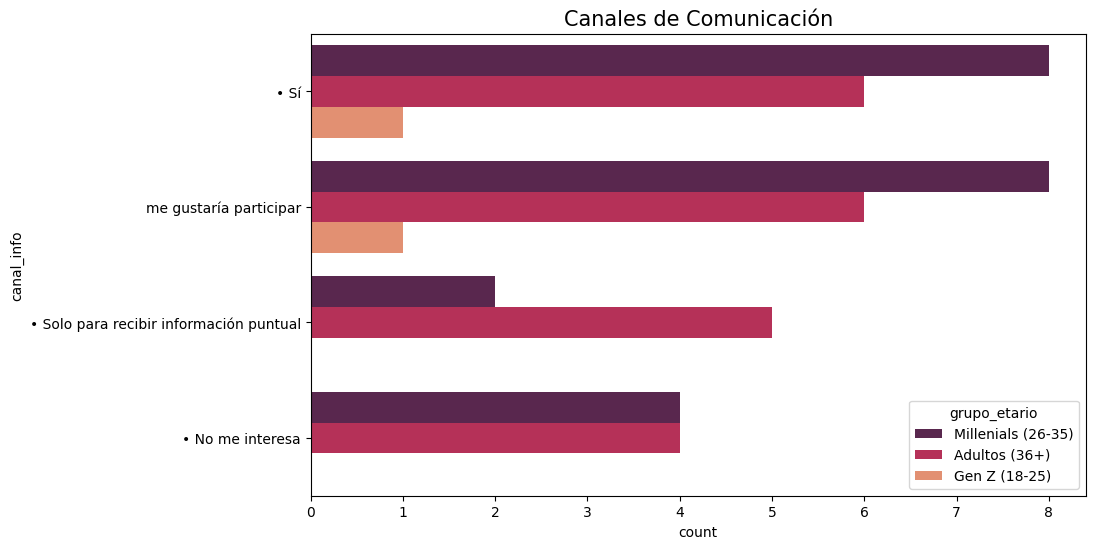

In [29]:
df_canales_ok = limpiar_multiseleccion(df, "canal_info")

# 2. Gráficamos
plt.figure(figsize=(10,6))
sns.countplot(
    data=df_canales_ok,
    y="canal_info",
    hue="grupo_etario", 
    palette="rocket"
)
plt.title("Canales de Comunicación", fontsize=15)
plt.savefig(FIGURES_DIR / "05_canales_comunicacion.png", dpi=300, bbox_inches="tight")
plt.show()

### 🧠 Nota Técnica: Regex para Limpieza de Datos
Se implementó una **Expresión Regular (Regex)** avanzada: `r',(?![^\(]*\))'`. 

**¿Qué hace?** Busca una coma, pero mira hacia adelante para asegurarse de que esa coma **no** esté dentro de un paréntesis. Esto permite que la opción *"Eventos sociales (Cenas, música en directo)"* se mantenga como una sola unidad, mientras que separa correctamente otras opciones distintas.

## 🏁 Conclusiones del Análisis Exploratorio (EDA)

Tras corregir los sesgos de limpieza en las preguntas de multiselección, los datos arrojan tres pilares para la estrategia de la parroquia:
1. **El Deporte como Puente:** Es la actividad con mayor consenso entre Gen Z y Millenials. Una "Liga parroquial" o "Rutas del Camino" son éxito seguro.
2. **La paradoja del interés social:** Los adultos piden más eventos sociales que los propios jóvenes. Esto sugiere que los jóvenes quizás ven la parroquia como un lugar de *acción* (voluntariado/deporte) y no tanto de *reunión pasiva* (cenas).
3. **Comunicación Digital:** Existe una disposición clara a participar ("Si, me gustaria participar"), pero falta el canal que active esa intención.

> **Siguiente Paso:** Con estos grupos tan definidos, vamos a usar el **Clustering (K-means)** para ver si hay "perfiles ocultos" dentro de los jóvenes.